In [4]:
!pip install langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.6 MB/s eta 0:00:00


In [57]:
from pydantic import BaseModel
from typing import TypedDict, List, Literal

# -----------------------------
# Graph State
# -----------------------------

class State(TypedDict):
    prompt_generated: str
    task: str
    feedback: str
    grade: str
    history: List[str]
    attempts: int

# -----------------------------
# Structured evaluation output
# -----------------------------

class ClauseFeedback(BaseModel):
    grade: Literal["acceptable", "needs revision"]
    feedback: str

In [48]:
# API KEYS
import os
key_gem = ""
os.environ["GOOGLE_API_KEY"] = key_gem

In [79]:
# from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI

# llm = ChatOpenAI(model="gpt-4o-mini")
llm = ChatGoogleGenerativeAI(model="gemini-2.5-pro", temperature=0)
evaluator = llm.with_structured_output(ClauseFeedback)

In [80]:
# -----------------------------
# Generator
# -----------------------------
def generate_prompt(state):

    attempts = state.get("attempts", 0) + 1
    if state.get("feedback"):
        prompt = f"""
Create a high-quality LLM prompt for the task: {state['task']}.

Improve the prompt using the feedback below.

Feedback:
{state['feedback']}
"""
    else:
        prompt = f"""
Create a prompt for the following task:

Task: {state['task']}

The prompt should include:
- role definition
- clear instructions
- expected output format
"""

    msg = llm.invoke(prompt)

    prompt_generated = msg.content

    history = state.get("history", [])
    history.append(f"\nPROPOSED prompt_generated:\n{prompt_generated}")

    return {"prompt_generated": prompt_generated, "history": history,"attempts":attempts}

In [81]:
# -----------------------------
# Evaluator
# -----------------------------

def evaluate_prompt(state: State):

    result = evaluator.invoke(f"""
You are a prompt engineering expert.

Evaluate the following prompt.

A good prompt must include:

1. Role definition
2. Clear task instruction
3. Output format
4. Constraints or guidelines
5. Clarity and specificity

If any are missing return "Rejected".

Prompt:
{state['prompt_generated']}
""")

    history = state.get("history", [])
    history.append(
        f"\nEVALUATION:\nGrade: {result.grade}\nFeedback: {result.feedback}"
    )

    return {
        "grade": result.grade,
        "feedback": result.feedback,
        "history": history,
    }


In [82]:
def route_clause(state: State):
    MAX_ATTEMPTS = 3
    if state["grade"] == "acceptable":
        return "Accepted"
    elif state["attempts"] >= MAX_ATTEMPTS:
        return "Accepted"   # stop even if not perfect
    return "Rejected"

In [83]:
from langgraph.graph import StateGraph, START, END

# -----------------------------
# Graph
# -----------------------------

builder = StateGraph(State)

builder.add_node("generate_prompt", generate_prompt)
builder.add_node("evaluate_prompt", evaluate_prompt)

builder.add_edge(START, "generate_prompt")
builder.add_edge("generate_prompt", "evaluate_prompt")

builder.add_conditional_edges(
    "evaluate_prompt",
    route_clause,
    {
        "Accepted": END,
        "Rejected": "generate_prompt",
    },
)

workflow = builder.compile()

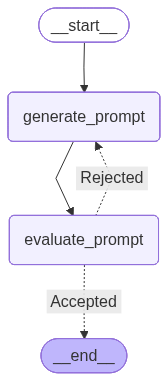

In [84]:
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))

In [85]:
state = workflow.invoke(
    {
        "task": "you are a data analyst. you neeed to summarize the given input data into executive level",
        "history": [],
         "attempts": 0
    }
)

In [86]:
for m in state["history"]:
    print(m)
    print("\n------------------------------\n")


PROPOSED prompt_generated:
Of course! Here is a comprehensive and reusable prompt for generating an executive-level summary from data.

---

### Prompt:

**Role:** You are an expert Data Analyst specializing in business intelligence and strategic communication. Your primary skill is transforming complex datasets into clear, concise, and actionable insights for a non-technical, executive audience (e.g., CEO, CFO, VPs). You understand that executives care about the "so what"—the bottom-line impact on business goals like revenue, costs, risk, and opportunity.

**Task:** Analyze the input data provided below and generate a high-level executive summary. Your summary must distill the most critical information, identify significant trends, and provide strategic recommendations based on your findings. Avoid technical jargon and focus on the business implications of the data.

**Instructions:**
1.  **Identify Key Performance Indicators (KPIs):** Pinpoint the 3-4 most important metrics from the